## Setup
We import all required libraries and define the downsample factor (FACTOR = 10).
The raw raster files from ICNF are at 25m resolution. This factor will be used 
later to divide the original raster dimensions by 10 when loading them, making 
each pixel represent 250m instead of 25m and reducing the number of pixels by 
100x. This makes it possible to process multiple large national-scale rasters 
simultaneously without running out of memory.

In [1]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from rasterio.plot import show
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask as rasterio_mask
from rasterio.features import rasterize
from shapely.geometry import mapping, box
import pandas as pd
import os
import gc

# Downsample factor
FACTOR = 10

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data
### 1.1 Load Portugal Boundary
We load a shapefile containing world country boundaries and filter it to 
Portugal. Since Portugal includes the Azores and Madeira islands, which are 
far from the mainland, we clip the result to a bounding box that only keeps 
mainland Portugal. Without this step, every map would zoom out to fit all 
three territories, making the mainland unreadable. The coordinates of the 
bounding box are in metres in EPSG:3763, the official Portuguese national 
projection. We reproject everything to EPSG:3763 from the start because it 
measures distances in metres rather than degrees, which is essential for any 
area or distance calculations to be accurate. Every other layer in the project 
uses this same CRS so everything needs to match.

In [2]:
world = gpd.read_file("../data/raw/portugal_boundaries/ne_10m_admin_0_countries_prt.shp").to_crs("EPSG:3763")
portugal = world[world["ADMIN"] == "Portugal"]
mainland_bbox = box(-150000, -350000, 150000, 350000)
portugal_mainland = portugal.clip(mainland_bbox)
print("Portugal boundary loaded:", portugal_mainland.shape)

Portugal boundary loaded: (1, 169)


### 1.2 Load Vector Datasets
We load all the vector layers needed for the risk model: burned area perimeters 
(one file per year, 2021–2024), critical fire locations, vegetation index, 
aridity index and the primary fuel management network. After loading each file 
we print its shape as a quick sanity check to confirm it loaded correctly and 
contains a reasonable number of features.

In [3]:
# Burned areas per year
burned_2021 = gpd.read_file("../data/raw/burned_areas/burned_2021/ardida_2021.shp")
burned_2022 = gpd.read_file("../data/raw/burned_areas/burned_2022/ardida_2022.shp")
burned_2023 = gpd.read_file("../data/raw/burned_areas/burned_2023/ardida_2023.shp")
burned_2024 = gpd.read_file("../data/raw/burned_areas/burned_2024/ardida_2024.shp")

# Other risk factor layers
critical_locations = gpd.read_file("../data/raw/critical_fire_locations/critical_location.shp")
vegetation = gpd.read_file("../data/raw/vegetation_index/iqv_2000.shp")
aridity = gpd.read_file("../data/raw/aridity_index/aridity_index_2000_2010.shp")
fuel_network = gpd.read_file("../data/raw/primary_fuel_management_network/primary_network.shp")

print("Burned areas 2021:", burned_2021.shape)
print("Burned areas 2022:", burned_2022.shape)
print("Burned areas 2023:", burned_2023.shape)
print("Burned areas 2024:", burned_2024.shape)
print("Critical locations:", critical_locations.shape)
print("Vegetation:", vegetation.shape)
print("Aridity:", aridity.shape)
print("Fuel network:", fuel_network.shape)

Burned areas 2021: (918, 23)
Burned areas 2022: (1786, 24)
Burned areas 2023: (1736, 24)
Burned areas 2024: (1558, 23)
Critical locations: (8265, 23)
Vegetation: (6, 4)
Aridity: (674, 4)
Fuel network: (5529, 11)


### 1.3 Load Hazard Rasters
We define the file paths and nodata values for each year's hazard raster 
(2021–2024). Each year was published by ICNF with a different nodata 
convention, so these are tracked separately to avoid them being treated 
as real hazard values later.

We then open the 2021 raster to read its metadata and use it to define 
the reference grid at 250m resolution (dividing the original dimensions 
by FACTOR = 10). This reference grid is used throughout the notebook to 
ensure all layers are aligned to the same spatial framework.

In [4]:
hazard_paths = {
    2021: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2021/perigosidade_conjuntural_2021.tif",
    2022: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2022/perigosidade_conjuntural_2022.tif",
    2023: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2023/perigosidade_conjuntural2023.tif",
    2024: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2024/PerigosidadeConjuntural_2024/perigosidade_conjuntural2024.tif",
}
nodata_values = {2021: 255, 2022: None, 2023: 15, 2024: 15}

# Get reference grid at 250m resolution
with rasterio.open(hazard_paths[2021]) as ref:
    ref_height = ref.height // FACTOR
    ref_width = ref.width // FACTOR
    ref_transform = ref.transform * ref.transform.scale(
        ref.width / ref_width,
        ref.height / ref_height
    )
    ref_crs = ref.crs
    ref_shape = (ref_height, ref_width)

print("Reference grid shape:", ref_shape)
print("Reference CRS:", ref_crs)

Reference grid shape: (2306, 1125)
Reference CRS: EPSG:3763


### 1.2 Create Portugal Mainland Mask
We convert the mainland Portugal polygon loaded in 1.1 into a raster mask 
at 250m resolution — a grid of True/False values where True means inside 
Portugal and False means outside. This is necessary because all risk 
calculations happen in raster format, so clipping raster data to the 
country boundary requires a raster mask, not a vector polygon.

In [5]:
from rasterio.features import geometry_mask
from shapely.geometry import mapping

portugal_geom = [mapping(geom) for geom in portugal_mainland.geometry]

port_mask = geometry_mask(
    portugal_geom,
    out_shape=ref_shape,
    transform=ref_transform,
    invert=True
)

print("Portugal mask created:", port_mask.shape)
print("Pixels inside Portugal:", port_mask.sum())

Portugal mask created: (2306, 1125)
Pixels inside Portugal: 1414222


## 2. Data Preparation
### 2.1 Merge Burned Areas and Prepare Vector Layers
We merge the four annual burned area layers into a single cumulative layer 
representing the full 2021–2024 period, keeping only the geometry column 
as the year label is not needed for the risk calculation.

We also convert the text categories in the vegetation and aridity layers 
into ordered numerical values, since raster calculations require numbers. 
For example "Baixa" (Low) becomes 1 and "Muito alta" (Very High) becomes 5 
for vegetation, and "Humido" (Humid) becomes 1 and "Semiarido" (Semi-arid) 
becomes 4 for aridity.

In [6]:
# Merge burned areas
cols = ["geometry"]
burned_all = pd.concat([
    burned_2021[cols], burned_2022[cols],
    burned_2023[cols], burned_2024[cols]
]).reset_index(drop=True)

print("Total fire perimeters:", len(burned_all))

# Convert vegetation categories to numerical values
vegetation_map = {
    'NoData': np.nan, 'Baixa': 1, 'Média': 2,
    'Moderada': 3, 'Alta': 4, 'Muito alta': 5
}
aridity_map = {
    'Humido': 1, 'Subhumido Humido': 2,
    'Subhumido Seco': 3, 'Semiarido': 4
}

vegetation["iqv_num"] = vegetation["iqv"].map(vegetation_map)
aridity["indaride_num"] = aridity["indaride"].map(aridity_map)

print("Vegetation values:", vegetation["iqv_num"].unique())
print("Aridity values:", aridity["indaride_num"].unique())

Total fire perimeters: 5998
Vegetation values: [nan  2.  3.  4.  5.  1.]
Aridity values: [nan  2.  1.  3.  4.]


### 2.2 Load and Normalise Hazard Rasters
We load each annual hazard raster at 250m resolution, mask out nodata and 
zero values, and normalise each year to a 0-1 scale before averaging. 

Normalisation is necessary because the four years use different original 
scales (2021 goes from 0 to 255, while 2023 and 2024 go from 0 to 15). 
Averaging the raw values directly would give 2021 a disproportionate 
influence simply because its numbers are larger, not because it represents 
higher hazard. Normalising to 0-1 first puts all four years on equal footing.

The four normalised layers are then averaged into a single mean hazard layer 
using nanmean, which ignores nodata pixels and averages only valid values, 
preventing a single missing year from corrupting the result.

In [7]:
hazard_arrays = []

for year, path in hazard_paths.items():
    with rasterio.open(path) as src:
        # Load at 250m resolution
        data = src.read(1, out_shape=ref_shape).astype("float32")
        
        # Mask nodata and zeros
        nd = nodata_values[year]
        if nd is not None:
            data[data == nd] = np.nan
        data[data == 0] = np.nan
        
        # Normalise to 0-1
        data_min = np.nanmin(data)
        data_max = np.nanmax(data)
        data = (data - data_min) / (data_max - data_min)
        hazard_arrays.append(data)

# Average across four years
hazard_mean = np.nanmean(np.stack(hazard_arrays, axis=0), axis=0)

print("Hazard mean shape:", hazard_mean.shape)
print("Hazard mean range:", np.nanmin(hazard_mean), "-", np.nanmax(hazard_mean))

Hazard mean shape: (2306, 1125)
Hazard mean range: 0.0 - 1.0


C:\Users\marta\AppData\Local\Temp\ipykernel_10944\3147644479.py:21: RuntimeWarning: Mean of empty slice
  hazard_mean = np.nanmean(np.stack(hazard_arrays, axis=0), axis=0)


### 2.3 Rasterise Vector Layers
We convert all four vector layers into rasters at 250m resolution, matching 
the reference grid defined in 1.3. This is necessary because the weighted 
overlay in 2.4 requires all layers to be in raster format so they can be 
combined pixel by pixel.

Burned areas are assigned a binary value (1 = burned, 0 = not burned) since 
a pixel either burned or it didn't. Critical locations, vegetation and aridity 
are assigned their actual numerical values to preserve their intensity ranking. 
Pixels that do not overlap any feature are filled with 0, which is later 
treated as nodata in 2.4.

In [8]:
portugal_geom = [mapping(geom) for geom in portugal_mainland.geometry]

# Burned areas — binary (burned=1, not burned=0)
burned_geoms = [(geom, 1) for geom in burned_all.geometry if geom is not None]
burned_raster = rasterize(
    burned_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

# Critical locations — use NivelCriti as value
critical_geoms = [(geom, val) for geom, val in
                  zip(critical_locations.geometry, critical_locations["NivelCriti"])
                  if geom is not None]
critical_raster = rasterize(
    critical_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

# Vegetation — use iqv_num as value
veg_geoms = [(geom, val) for geom, val in
             zip(vegetation.geometry, vegetation["iqv_num"])
             if geom is not None and not np.isnan(val)]
veg_raster = rasterize(
    veg_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

# Aridity — use indaride_num as value
arid_geoms = [(geom, val) for geom, val in
              zip(aridity.geometry, aridity["indaride_num"])
              if geom is not None and not np.isnan(val)]
arid_raster = rasterize(
    arid_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

print("Burned range:", burned_raster.min(), "-", burned_raster.max())
print("Critical range:", critical_raster.min(), "-", critical_raster.max())
print("Vegetation range:", veg_raster.min(), "-", veg_raster.max())
print("Aridity range:", arid_raster.min(), "-", arid_raster.max())

Burned range: 0.0 - 1.0
Critical range: 0.0 - 25.9366
Vegetation range: 0.0 - 5.0
Aridity range: 0.0 - 4.0


### 2.4 Normalise to 1–5 Scale and Apply Weighted Overlay
We normalise all layers to a common 1–5 scale and combine them into a 
single risk score using a weighted formula:

**Risk = 0.35 × Hazard + 0.20 × Critical Locations + 0.20 × Burned Areas 
     + 0.15 × Vegetation + 0.10 × Aridity**

Normalising to 1–5 is necessary because all layers come in different scales 
and need to be on the same scale to be combined fairly. Burned areas are 
assigned 5 if burned and 1 if not, reflecting that historical fire occurrence 
is a strong predictor of future risk.

Conjunctural hazard receives the highest weight (0.35) as it directly captures 
climate-driven fire danger. Burned areas and critical locations share 0.20 each 
as strong structural indicators. Vegetation and aridity receive lower weights 
as supporting factors.

The weight sum is tracked per pixel so that pixels where some layers are missing 
are not penalised, the final score is divided by the sum of weights that 
actually contributed to that pixel. Once normalised, the raw rasters are deleted 
and the garbage collector is called to free memory for the next steps.

In [9]:
def normalise_1_5(arr, binary=False):
    """Normalise array to 1-5 scale, treating 0 as nodata."""
    out = np.full(arr.shape, np.nan, dtype="float32")
    if binary:
        # burned = 5, not burned = 1
        out[arr == 1] = 5
        out[arr == 0] = 1
    else:
        mask = arr > 0
        if mask.sum() > 0:
            mn, mx = arr[mask].min(), arr[mask].max()
            if mx > mn:
                out[mask] = 1 + (arr[mask] - mn) / (mx - mn) * 4
            else:
                out[mask] = 1
        out[~mask] = np.nan
    return out

# Normalise each layer
hazard_1_5  = np.where(hazard_mean > 0, 1 + hazard_mean * 4, np.nan).astype("float32")
burned_1_5  = normalise_1_5(burned_raster, binary=True)
critical_1_5 = normalise_1_5(critical_raster)
veg_1_5     = normalise_1_5(veg_raster)
arid_1_5    = normalise_1_5(arid_raster)

# Free raw rasters from memory
del burned_raster, critical_raster, veg_raster, arid_raster
gc.collect()

# Weighted overlay — track weight sum per pixel to handle nodata
weights = {"hazard": 0.35, "critical": 0.20, "burned": 0.20, "veg": 0.15, "arid": 0.10}
layers  = {"hazard": hazard_1_5, "critical": critical_1_5,
           "burned": burned_1_5, "veg": veg_1_5, "arid": arid_1_5}

risk_model  = np.zeros(ref_shape, dtype="float32")
weight_sum  = np.zeros(ref_shape, dtype="float32")

for name, layer in layers.items():
    w = weights[name]
    mask = ~np.isnan(layer)
    risk_model[mask] += layer[mask] * w
    weight_sum[mask] += w

risk_model = np.where(weight_sum > 0, risk_model / weight_sum, np.nan)

print("Risk model range:", np.nanmin(risk_model), "-", np.nanmax(risk_model))
print("Risk model shape:", risk_model.shape)

Risk model range: 1.0 - 5.0
Risk model shape: (2306, 1125)


### 2.5 Load Municipality Boundaries
We load the official municipality boundaries for mainland Portugal. This layer 
is essential for the second part of the analysis, where pixel-level risk 
calculations are aggregated to the municipal level to answer the inequality 
research question. We print the shape, CRS, column names and first few rows 
as a more thorough sanity check, confirming the number of municipalities, 
that the CRS matches the rest of the project, and identifying which column 
contains the municipality name for joining with the INE data later.

In [10]:
municipalities = gpd.read_file("../data/raw/municipalities/concelhos_Project.shp")
print(municipalities.shape)
print(municipalities.crs)
print(municipalities.columns.tolist())
print(municipalities.head())

(281, 3)
EPSG:3763
['ObjectID', 'NAME', 'geometry']
   ObjectID           NAME                                           geometry
0        94        Setúbal  POLYGON ((-77793.528 -120594.573, -77605.067 -...
1        95  Vila Do Bispo  POLYGON ((-56876.481 -288057.984, -56957.02 -2...
2        96       Sesimbra  POLYGON ((-78862.629 -120548.788, -78716.522 -...
3       104          Moura  POLYGON ((86129.19 -167278.897, 86122.452 -167...
4       105         Tavira  POLYGON ((44589.473 -264189.183, 45191.197 -26...


## 3. Exploratory Analysis
### 3.1 Cumulative Burned Areas Map
We plot all burned area perimeters for 2021 to 2024 on a single map, with 
each year shown in a different colour to give an immediate visual overview 
of where fires occurred and whether certain areas burned repeatedly across 
the study period.

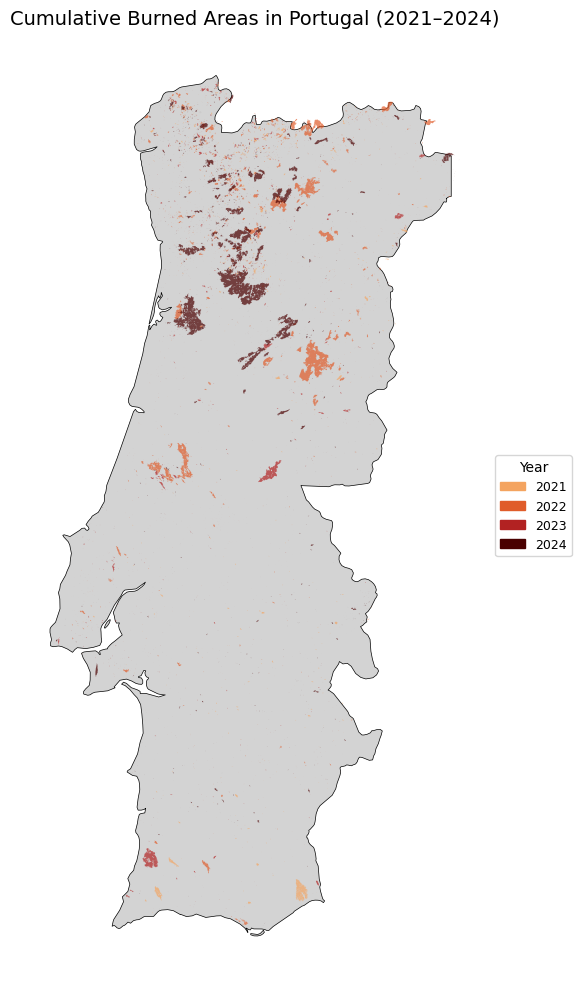

In [11]:
import matplotlib.patches as mpatches

# Add year column to each
burned_2021["year"] = 2021
burned_2022["year"] = 2022
burned_2023["year"] = 2023
burned_2024["year"] = 2024

cols = ["year", "geometry"]
burned_all_plot = pd.concat([
    burned_2021[cols], burned_2022[cols],
    burned_2023[cols], burned_2024[cols]
]).reset_index(drop=True)

colors = {2021: "#f4a460", 2022: "#e05c2a", 2023: "#b22222", 2024: "#4a0000"}

fig, ax = plt.subplots(figsize=(10, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)

for year, color in colors.items():
    burned_all_plot[burned_all_plot["year"] == year].plot(
        ax=ax, color=color, edgecolor="none", alpha=0.7
    )

patches = [mpatches.Patch(color=c, label=str(y)) for y, c in colors.items()]
ax.legend(handles=patches, title="Year", loc="center left",
          bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.set_title("Cumulative Burned Areas in Portugal (2021–2024)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/burned_areas_2021_2024.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Total Burned Area per Year
We calculate and visualise the total burned area in hectares for each year 
to highlight which years were most destructive and how fire severity varied 
across the years.

   year  total_area_ha
0  2021   27374.628894
1  2022  115148.600723
2  2023   34151.106022
3  2024  139396.848847


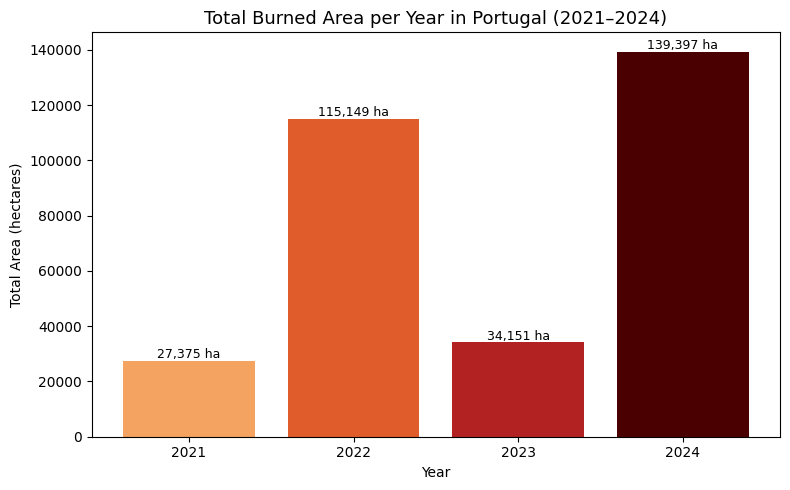

In [12]:
burned_all_plot["area_ha"] = burned_all_plot.geometry.area / 10000

summary = burned_all_plot.groupby("year")["area_ha"].sum().reset_index()
summary.columns = ["year", "total_area_ha"]

print(summary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary["year"], summary["total_area_ha"],
       color=["#f4a460", "#e05c2a", "#b22222", "#4a0000"])
ax.set_title("Total Burned Area per Year in Portugal (2021–2024)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Total Area (hectares)")
ax.set_xticks([2021, 2022, 2023, 2024])
for i, row in summary.iterrows():
    ax.text(row["year"], row["total_area_ha"] + 1000, 
            f"{row['total_area_ha']:,.0f} ha", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/burned_area_per_year.png", dpi=150)
plt.show()

### 3.3 Burned Areas by Year
We plot each year separately to show how the spatial distribution of fires 
shifted across the years, with the total burned area in hectares 
displayed for each year.

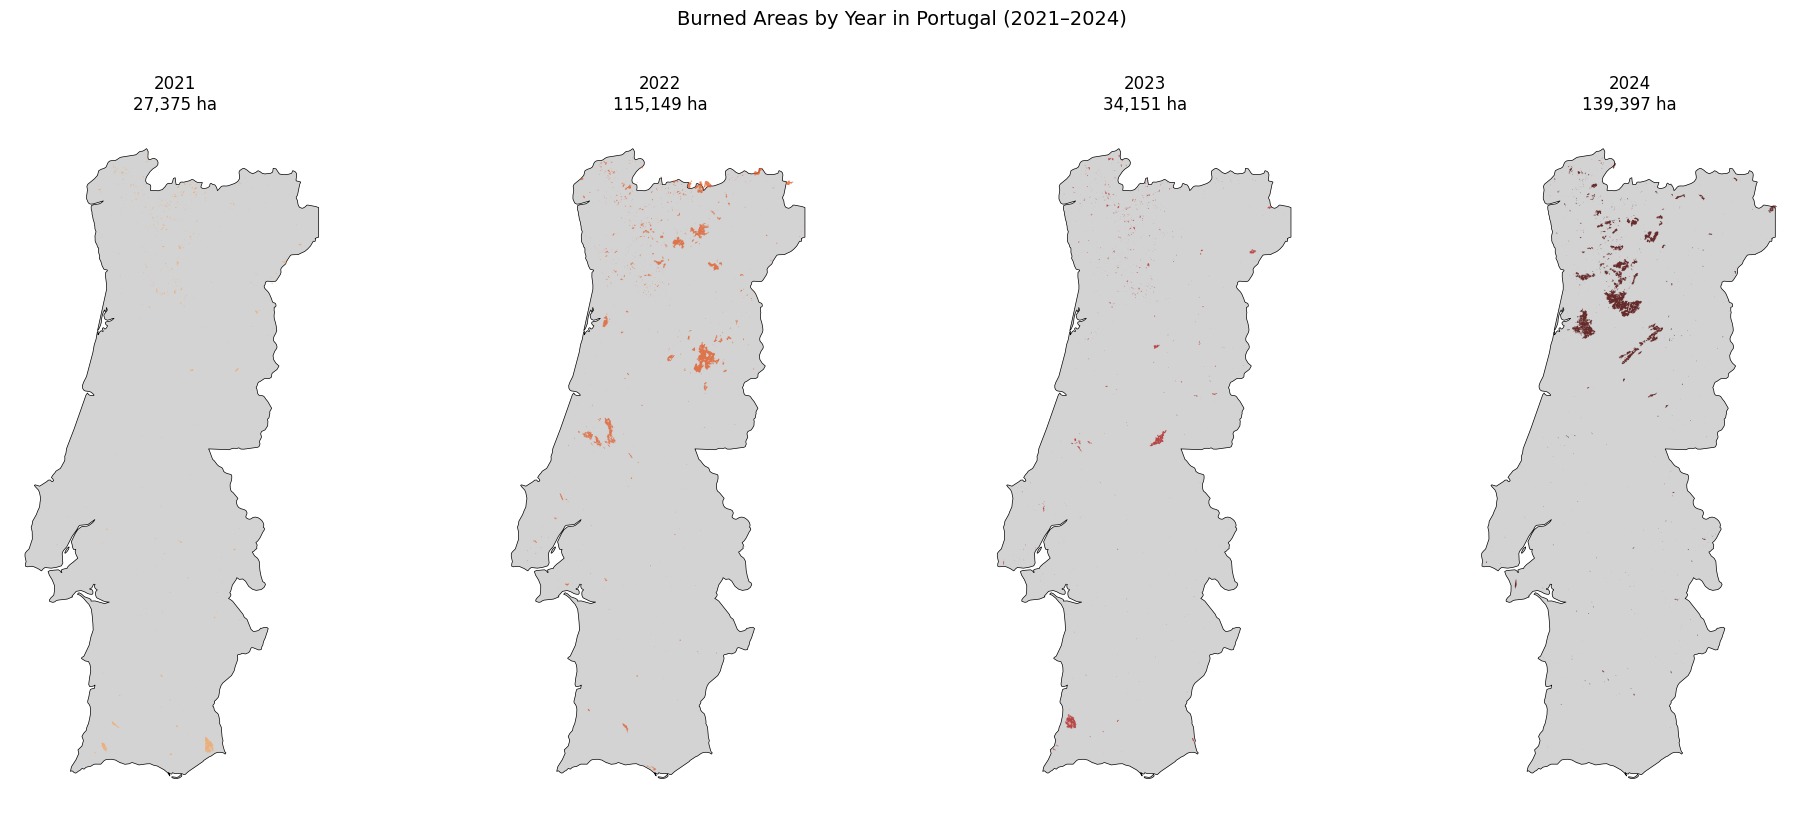

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 8))

for ax, (year, color) in zip(axes, colors.items()):
    portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
    burned_all_plot[burned_all_plot["year"] == year].plot(
        ax=ax, color=color, edgecolor="none", alpha=0.8
    )
    total = summary[summary["year"] == year]["total_area_ha"].values[0]
    ax.set_title(f"{year}\n{total:,.0f} ha", fontsize=12)
    ax.set_axis_off()

plt.suptitle("Burned Areas by Year in Portugal (2021–2024)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/burned_areas_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
print(f"2021: {len(burned_2021)}")
print(f"2022: {len(burned_2022)}")
print(f"2023: {len(burned_2023)}")
print(f"2024: {len(burned_2024)}")
print(f"Total: {len(burned_2021) + len(burned_2022) + len(burned_2023) + len(burned_2024)}")

2021: 918
2022: 1786
2023: 1736
2024: 1558
Total: 5998


### 3.4 Conjunctural Hazard by Year
We plot each year's hazard raster normalised to a 0-1 scale to visualise 
how climate-driven fire danger conditions varied spatially across mainland 
Portugal throughout the study period.

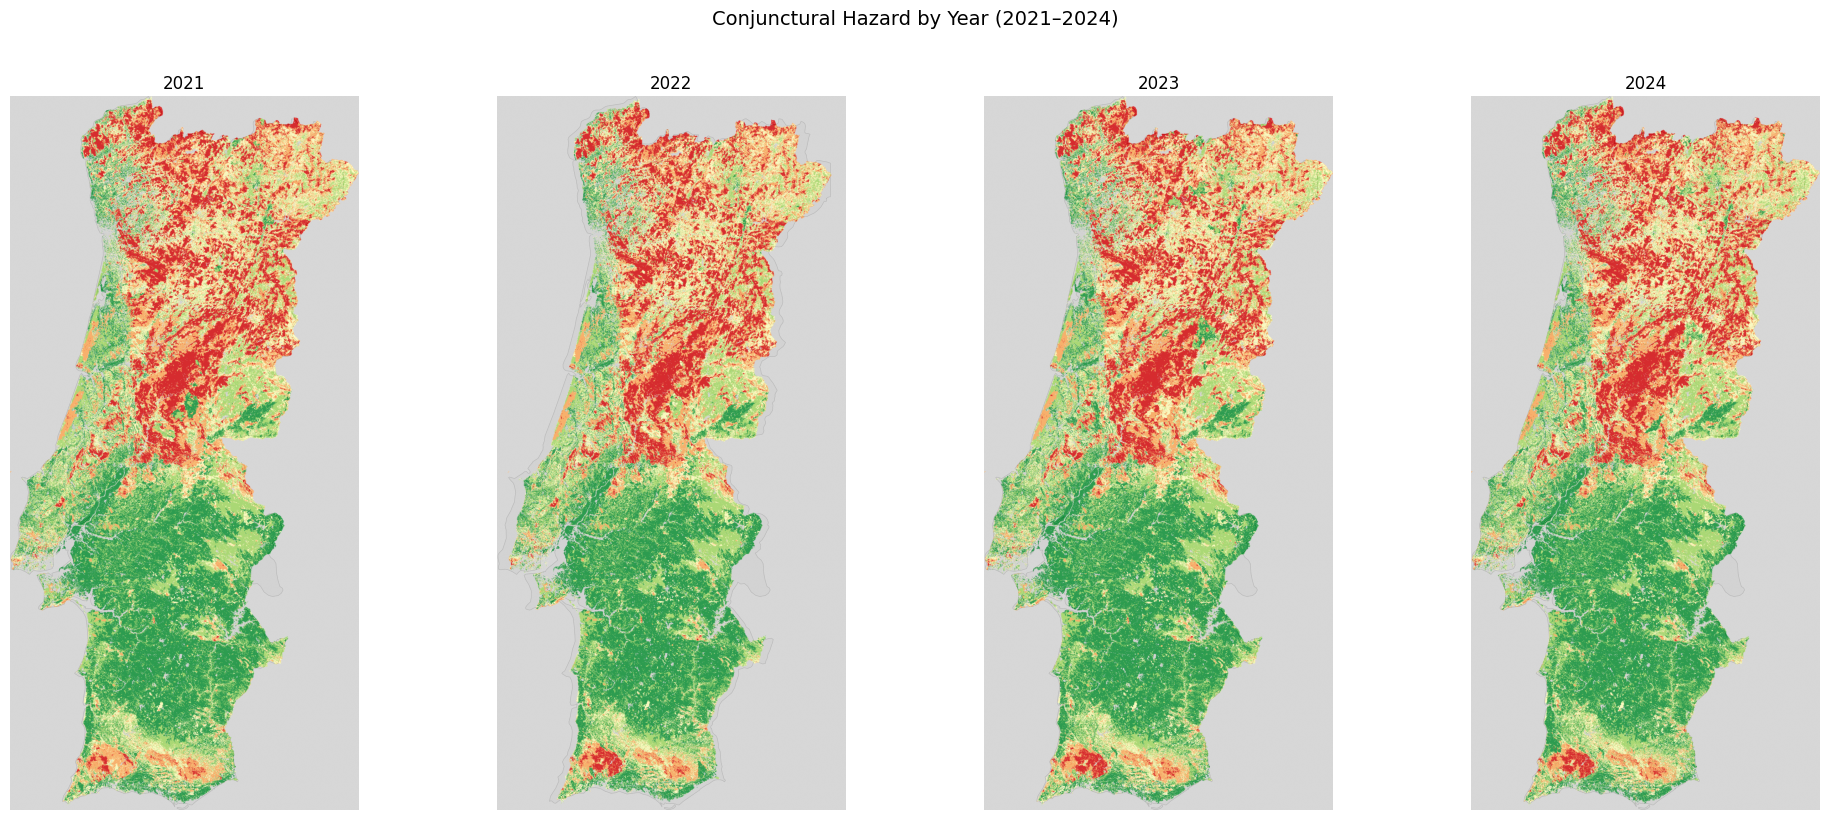

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 8))
colors_ramp = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
cmap_hazard = LinearSegmentedColormap.from_list("hazard", colors_ramp)
cmap_hazard.set_bad(color="lightgrey")

for ax, (year, path) in zip(axes, hazard_paths.items()):
    with rasterio.open(path) as src:
        data = src.read(1, out_shape=ref_shape).astype("float32")
        nd = nodata_values[year]
        if nd is not None:
            data[data == nd] = np.nan
        data[data == 0] = np.nan
        data_min = np.nanmin(data)
        data_max = np.nanmax(data)
        data = (data - data_min) / (data_max - data_min)

    portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5, zorder=1)
    show(data, transform=ref_transform, ax=ax, cmap=cmap_hazard, zorder=2, alpha=0.9)
    ax.set_title(f"{year}", fontsize=12)
    ax.set_axis_off()

plt.suptitle("Conjunctural Hazard by Year (2021–2024)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/hazard_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.5 Mean Conjunctural Hazard (2021–2024)
We plot the averaged hazard layer across the four years, providing a 
single map of overall climate-driven fire danger conditions across 
mainland Portugal for the full study period.

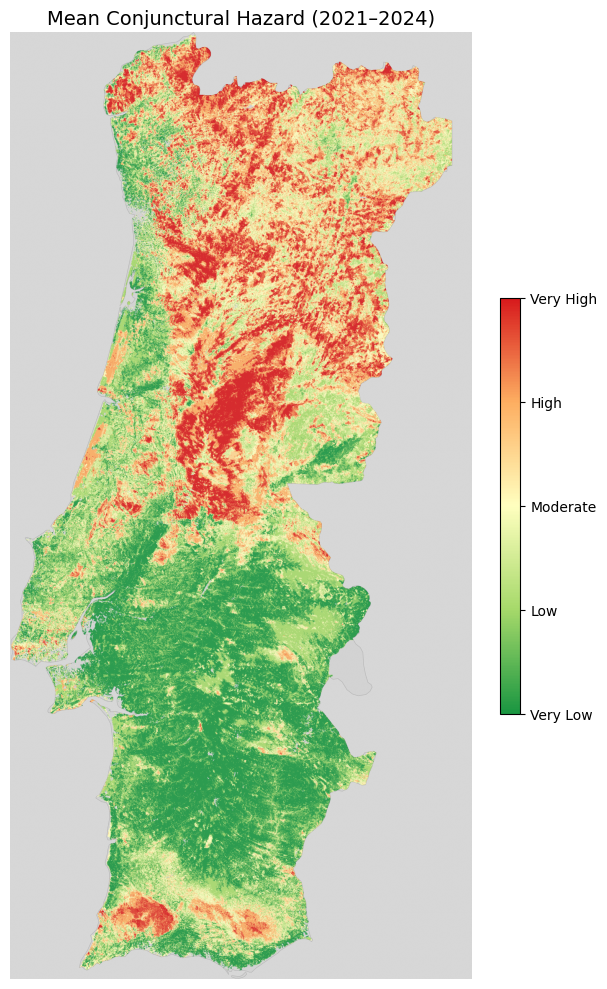

In [16]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

colors_ramp = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
cmap_hazard = LinearSegmentedColormap.from_list("hazard", colors_ramp)
cmap_hazard.set_bad(color="lightgrey")

hazard_display = np.where(port_mask, hazard_mean, np.nan)

fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5, zorder=1)
show(hazard_display, transform=ref_transform, ax=ax, cmap=cmap_hazard, zorder=2, alpha=0.9)

# Add colorbar legend
sm = ScalarMappable(cmap=cmap_hazard, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["Very Low", "Low", "Moderate", "High", "Very High"])

ax.set_title("Mean Conjunctural Hazard (2021–2024)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/mean_hazard.png", dpi=150)
plt.show()

### 3.6 Vegetation Index
We plot the vegetation quality index across mainland Portugal, where higher 
values indicate denser and more continuous vegetation cover and therefore 
greater fuel availability for fires.

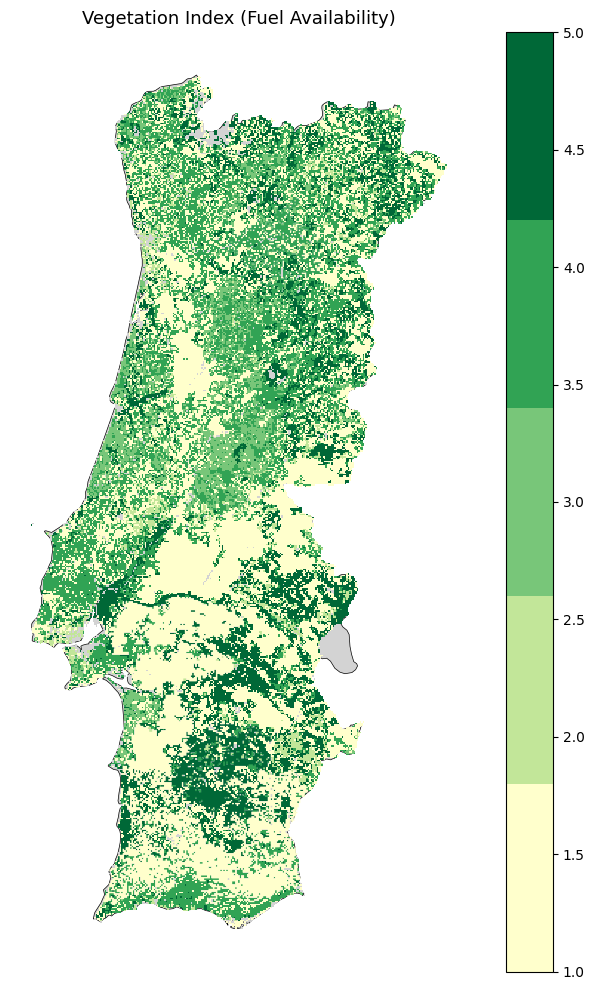

In [17]:
colors_veg = ["#ffffcc", "#c2e699", "#78c679", "#31a354", "#006837"]
cmap_veg = LinearSegmentedColormap.from_list("veg", colors_veg, N=5)

fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
vegetation.plot(ax=ax, column="iqv_num", cmap=cmap_veg,
                legend=True, missing_kwds={"color": "lightgrey"})
ax.set_title("Vegetation Index (Fuel Availability)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/vegetation_index.png", dpi=150)
plt.show()

### 3.7 Aridity Index
We plot the aridity index across mainland Portugal, where higher values 
indicate drier conditions that increase fuel desiccation and fire 
susceptibility.

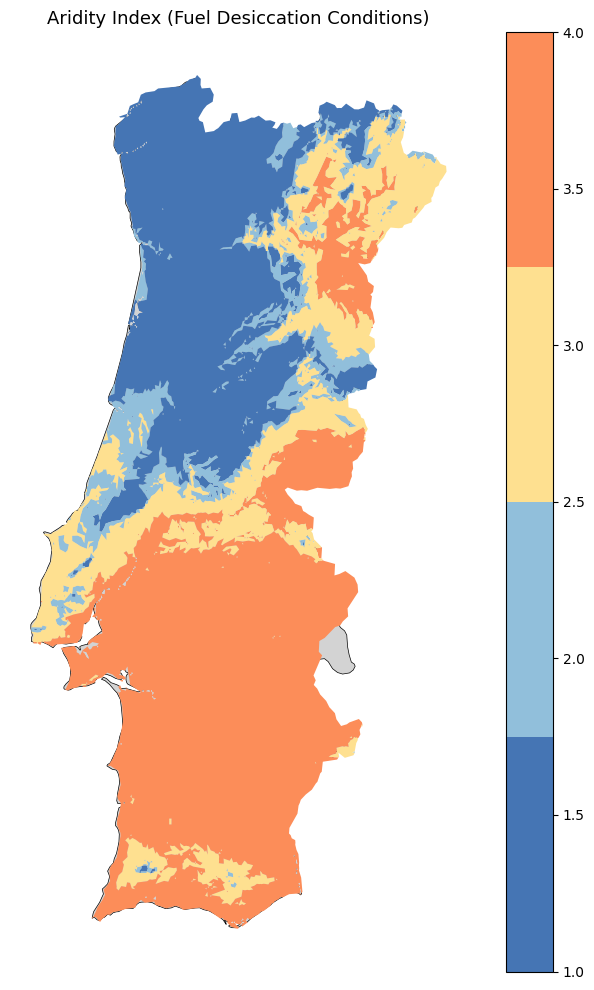

In [18]:
colors_arid = ["#4575b4", "#91bfdb", "#fee090", "#fc8d59"]
cmap_arid = LinearSegmentedColormap.from_list("arid", colors_arid, N=4)

fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
aridity.plot(ax=ax, column="indaride_num", cmap=cmap_arid,
             legend=True, missing_kwds={"color": "lightgrey"})
ax.set_title("Aridity Index (Fuel Desiccation Conditions)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/aridity_index.png", dpi=150)
plt.show()

### 3.8 Critical Fire Locations
We plot the structurally fire-prone locations across mainland Portugal. 
These are areas with dense uninterrupted vegetation and difficult access 
that represent persistent territorial risk independent of annual climate 
conditions.

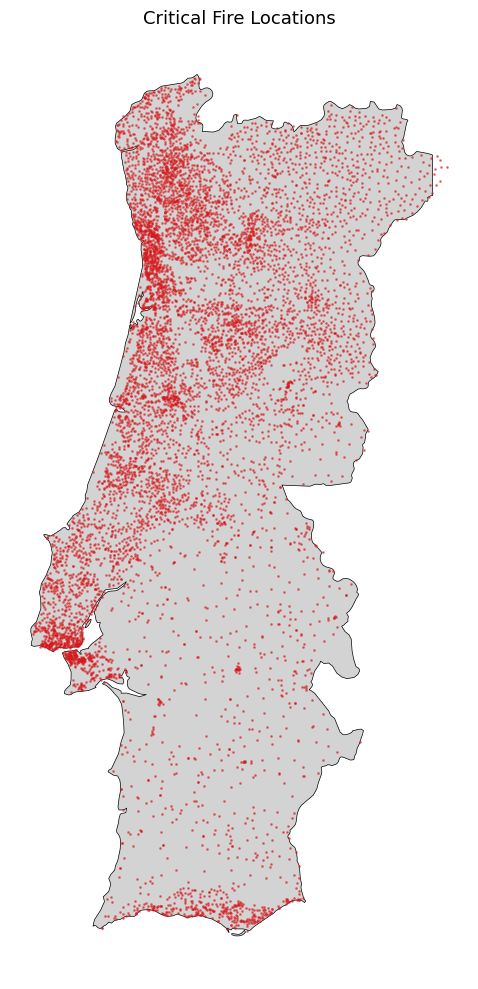

In [19]:
fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
critical_locations.plot(ax=ax, color="#d7191c", markersize=1, alpha=0.5)
ax.set_title("Critical Fire Locations", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/critical_locations.png", dpi=150)
plt.show()

### 3.9 Primary Fuel Management Network
We plot the primary fuel management network across mainland Portugal. 
This is the prevention infrastructure designed to slow fire spread by 
creating vegetation breaks across the territory.

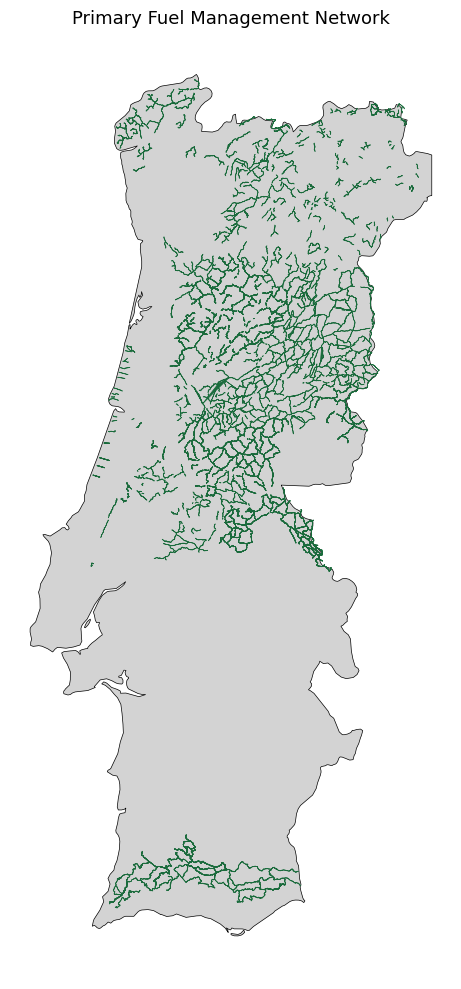

In [20]:
fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
fuel_network.plot(ax=ax, color="#1a6b3c", edgecolor="#1a6b3c", linewidth=0.5, alpha=1)
ax.set_title("Primary Fuel Management Network", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/fuel_network.png", dpi=150)
plt.show()

### 3.10 Classify and Visualise the Wildfire Risk Map
We classify the continuous risk values into five equal interval categories 
and plot the final national wildfire risk map. Equal interval classification 
divides the full range of risk values into five bands of the same width, 
assigning each pixel to a class from 1 (Very Low) to 5 (Very High).

Category counts:
  Class 1 : 155,438 pixels (10.7%)
  Class 2 : 699,722 pixels (48.2%)
  Class 3 : 528,068 pixels (36.4%)
  Class 4 : 63,447 pixels (4.4%)
  Class 5 : 5,433 pixels (0.4%)


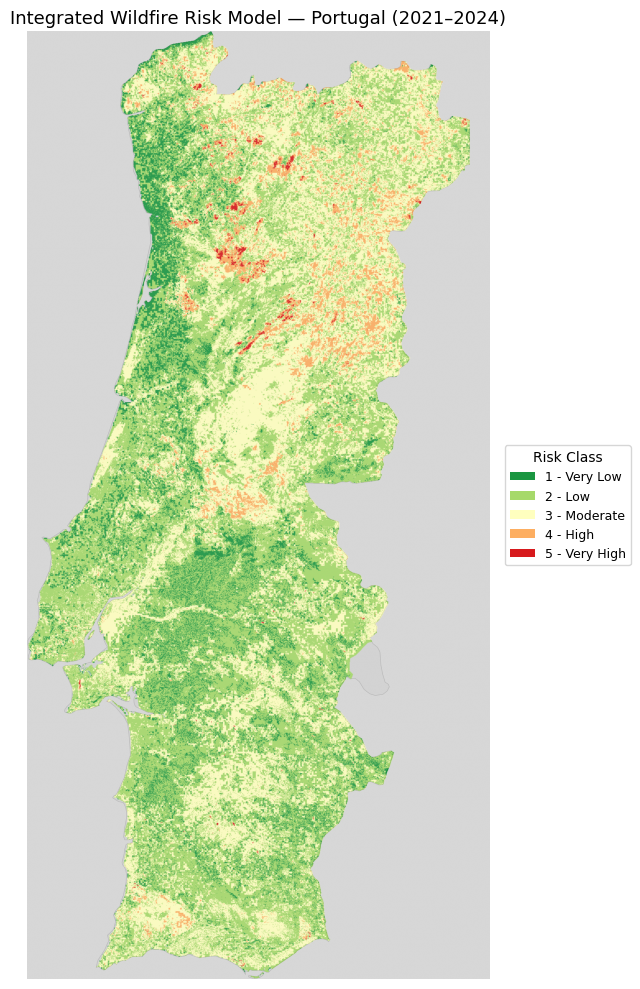

In [21]:
# Define colour map and legend
colors_risk = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
cmap_risk = LinearSegmentedColormap.from_list("risk", colors_risk, N=5)
cmap_risk.set_bad(color="lightgrey")

legend_elements = [
    Patch(facecolor="#1a9641", label="1 - Very Low"),
    Patch(facecolor="#a6d96a", label="2 - Low"),
    Patch(facecolor="#ffffbf", label="3 - Moderate"),
    Patch(facecolor="#fdae61", label="4 - High"),
    Patch(facecolor="#d7191c", label="5 - Very High"),
]

# Equal interval classification into 5 classes
risk_min = np.nanmin(risk_model)
risk_max = np.nanmax(risk_model)
interval = (risk_max - risk_min) / 5

risk_classified = np.where(
    ~np.isnan(risk_model),
    np.clip(np.ceil((risk_model - risk_min) / interval), 1, 5),
    np.nan
)

# Remove pixels where only the burned layer contributed —
# these are areas like Olivença where the boundary shapefile
# includes territory not covered by any ICNF data
only_burned = (weight_sum == 0.20)
risk_classified = np.where(only_burned, np.nan, risk_classified)

# Print distribution
print("Category counts:")
total = np.sum(~np.isnan(risk_classified))
for cat in [1, 2, 3, 4, 5]:
    count = np.sum(risk_classified == cat)
    print(f"  Class {int(cat)} : {count:,} pixels ({count/total*100:.1f}%)")

# Mask to Portugal boundary
from rasterio.features import geometry_mask
port_mask = geometry_mask(
    portugal_geom,
    out_shape=ref_shape,
    transform=ref_transform,
    invert=True
)
risk_display = np.where(port_mask, risk_classified, np.nan)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5, zorder=1)
show(risk_display, transform=ref_transform, ax=ax, cmap=cmap_risk,
     vmin=1, vmax=5, zorder=2, alpha=0.9)
ax.legend(handles=legend_elements, loc="center left",
          bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Risk Class")
ax.set_title("Integrated Wildfire Risk Model — Portugal (2021–2024)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/wildfire_risk_map.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.11 Wildfire Risk Map with Primary Fuel Management Network
We overlay the primary fuel management network on top of the risk map 
to provide a first visual assessment of how prevention infrastructure 
aligns with the highest risk zones across mainland Portugal.

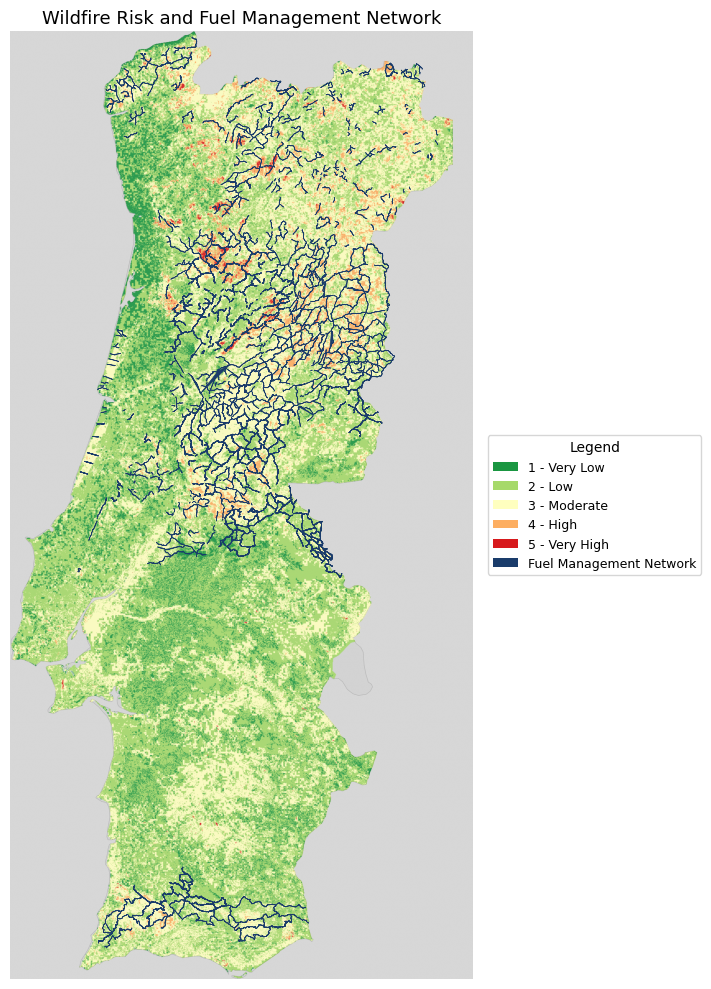

In [22]:
legend_elements_overlay = [
    Patch(facecolor="#1a9641", label="1 - Very Low"),
    Patch(facecolor="#a6d96a", label="2 - Low"),
    Patch(facecolor="#ffffbf", label="3 - Moderate"),
    Patch(facecolor="#fdae61", label="4 - High"),
    Patch(facecolor="#d7191c", label="5 - Very High"),
    Patch(facecolor="#1a3c6b", label="Fuel Management Network"),
]

fig, ax = plt.subplots(figsize=(10, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5, zorder=1)
show(risk_display, transform=ref_transform, ax=ax, cmap=cmap_risk,
     vmin=1, vmax=5, zorder=2, alpha=0.9)
fuel_network.plot(ax=ax, color="#1a3c6b", edgecolor="#1a3c6b", linewidth=0.5, zorder=3)
ax.legend(handles=legend_elements_overlay, loc="center left", 
          bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Legend")
ax.set_title("Wildfire Risk and Fuel Management Network", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/risk_fuel_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Coverage Gap Analysis
### 4.1 Extract High Risk Zones
We extract only the pixels classified as class 4 (High) and class 5 
(Very High) from the risk model, as these represent the areas where 
the absence of prevention infrastructure carries the greatest potential 
consequences. We also calculate and visualise the total area in km² 
assigned to each risk class, where each pixel covers 0.0625 km² 
(250m × 250m).

Area by risk class:
  Class 1: 9,714.9 km2
  Class 2: 43,732.6 km2
  Class 3: 33,004.2 km2
  Class 4: 3,965.4 km2
  Class 5: 339.6 km2

Total high risk area (class 4+5): 4,305.0 km2


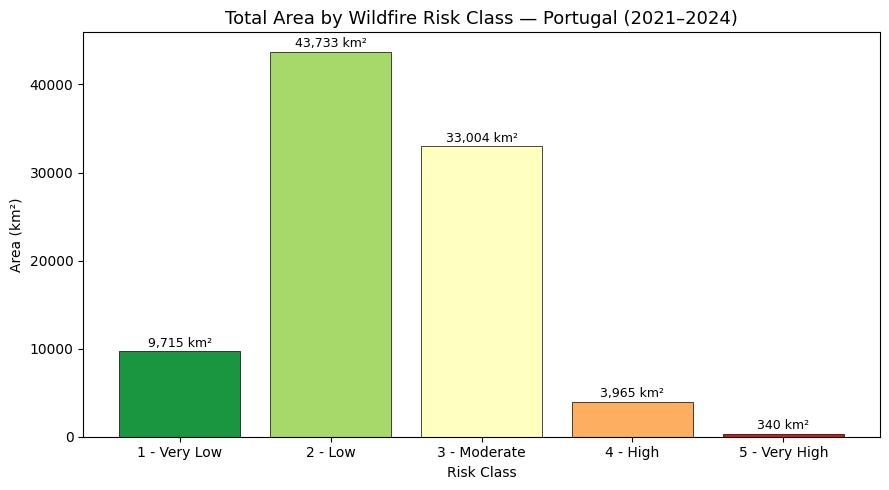

In [23]:
# Extract high risk pixels (class 4 and 5)
high_risk_mask = (risk_classified >= 4) & (~np.isnan(risk_classified))

# Calculate area per risk class
pixel_area_km2 = (250 * 250) / 1e6  # each pixel is 250m x 250m = 0.0625 km2

print("Area by risk class:")
total_valid = 0
for cat in [1, 2, 3, 4, 5]:
    count = np.sum(risk_classified == cat)
    area = count * pixel_area_km2
    total_valid += count
    print(f"  Class {int(cat)}: {area:,.1f} km2")

high_risk_area = np.sum(high_risk_mask) * pixel_area_km2
print(f"\nTotal high risk area (class 4+5): {high_risk_area:,.1f} km2")

# Bar chart
categories = [1, 2, 3, 4, 5]
labels = ["1 - Very Low", "2 - Low", "3 - Moderate", "4 - High", "5 - Very High"]
areas = [np.sum(risk_classified == cat) * pixel_area_km2 for cat in categories]
bar_colors = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, areas, color=bar_colors, edgecolor="black", linewidth=0.5)
for bar, area in zip(bars, areas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{area:,.0f} km²", ha="center", fontsize=9)
ax.set_title("Total Area by Wildfire Risk Class — Portugal (2021–2024)", fontsize=13)
ax.set_xlabel("Risk Class")
ax.set_ylabel("Area (km²)")
plt.tight_layout()
plt.savefig("../outputs/area_by_risk_class.png", dpi=150)
plt.show()

### 4.2 Create Buffer Around Fuel Management Network
We create buffer zones around the primary fuel management network at 
three distances: 500m, 1km and 2km. A high risk pixel is considered 
covered if it falls within the buffer. We test three distances to assess 
how sensitive the results are to this methodological choice. At 250m 
resolution, the buffers are computed by expanding the rasterised network 
by 2, 4 and 8 pixels respectively in all directions.

In [24]:
from rasterio.features import rasterize
from shapely.geometry import mapping

# Rasterise fuel network first
fuel_raster = rasterize(
    [(geom, 1) for geom in fuel_network.geometry if geom is not None],
    out_shape=ref_shape,
    transform=ref_transform,
    fill=0,
    dtype="uint8"
)

print("Fuel network rasterised:", fuel_raster.shape)
print("Fuel pixels:", np.sum(fuel_raster == 1))

Fuel network rasterised: (2306, 1125)
Fuel pixels: 19000


In [25]:
from scipy.ndimage import binary_dilation

# At 250m resolution:
# 500m = 2 pixels, 1km = 4 pixels, 2km = 8 pixels
fuel_bool = fuel_raster == 1

buffer_500_raster  = binary_dilation(fuel_bool, iterations=2)
buffer_1000_raster = binary_dilation(fuel_bool, iterations=4)
buffer_2000_raster = binary_dilation(fuel_bool, iterations=8)

print("500m buffer pixels:", np.sum(buffer_500_raster))
print("1km buffer pixels:", np.sum(buffer_1000_raster))
print("2km buffer pixels:", np.sum(buffer_2000_raster))

500m buffer pixels: 122930
1km buffer pixels: 227568
2km buffer pixels: 394336


### 4.3 Calculate National Coverage Statistics
We calculate what proportion of the high risk area (classes 4 and 5) 
falls within each buffer distance of the primary fuel management network. 
This directly answers the first part of our research question: how 
effectively does the infrastructure cover high risk zones at the 
national scale.

In [26]:
# High risk mask (class 4+5)
high_risk_mask = (risk_classified >= 4) & (~np.isnan(risk_classified))
total_high_risk = np.sum(high_risk_mask)
pixel_area_km2 = (250 * 250) / 1e6

results = []
for name, buf in [("500m", buffer_500_raster), 
                   ("1km", buffer_1000_raster), 
                   ("2km", buffer_2000_raster)]:
    covered = np.sum(high_risk_mask & buf)
    uncovered = total_high_risk - covered
    coverage_pct = covered / total_high_risk * 100
    gap_pct = uncovered / total_high_risk * 100
    results.append({
        "Buffer": name,
        "Total High Risk (km²)": total_high_risk * pixel_area_km2,
        "Covered (km²)": covered * pixel_area_km2,
        "Uncovered (km²)": uncovered * pixel_area_km2,
        "Coverage (%)": round(coverage_pct, 1),
        "Gap (%)": round(gap_pct, 1)
    })

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Buffer  Total High Risk (km²)  Covered (km²)  Uncovered (km²)  Coverage (%)  Gap (%)
  500m                 4305.0       940.0625        3364.9375          21.8     78.2
   1km                 4305.0      1670.7500        2634.2500          38.8     61.2
   2km                 4305.0      2660.0625        1644.9375          61.8     38.2


### 4.4 Visualise National Coverage — Stacked Bar Chart
We visualise the proportion of high risk area covered versus uncovered 
for each of the three buffer distances in a stacked bar chart, giving 
a clear overview of how coverage improves as the buffer distance increases.

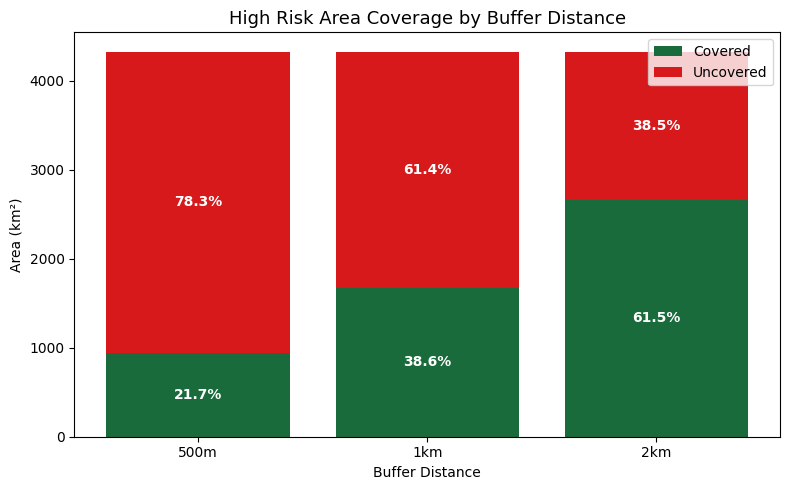

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

buffers = ["500m", "1km", "2km"]
covered = [940.06, 1670.75, 2660.50]
uncovered = [3386.50, 2655.81, 1666.06]

ax.bar(buffers, covered, color="#1a6b3c", label="Covered")
ax.bar(buffers, uncovered, bottom=covered, color="#d7191c", label="Uncovered")

for i, (c, u) in enumerate(zip(covered, uncovered)):
    total = c + u
    ax.text(i, c/2, f"{c/total*100:.1f}%", ha="center", va="center", 
            color="white", fontsize=10, fontweight="bold")
    ax.text(i, c + u/2, f"{u/total*100:.1f}%", ha="center", va="center",
            color="white", fontsize=10, fontweight="bold")

ax.set_title("High Risk Area Coverage by Buffer Distance", fontsize=13)
ax.set_xlabel("Buffer Distance")
ax.set_ylabel("Area (km²)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../outputs/national_coverage_stacked.png", dpi=150)
plt.show()

### 4.5 Municipal Level Coverage Analysis
We calculate coverage statistics for each municipality using the 1km 
buffer as the primary analysis distance. For each municipality we compute 
the total high risk area, the covered portion, the uncovered portion, the 
coverage ratio and the gap ratio. The results are first sorted by gap ratio 
to identify the most relatively unprotected municipalities, then re-sorted 
by absolute uncovered area and filtered to exclude municipalities with less 
than 1km² of high risk area, to avoid the ranking being dominated by very 
small territories.

In [28]:
from rasterio.features import rasterize
import geopandas as gpd

# Reproject municipalities to match raster CRS (already EPSG:3763)
muni = municipalities.copy()

municipal_stats = []

for idx, row in muni.iterrows():
    geom = row.geometry
    name = row["NAME"]
    
    # Rasterise municipality boundary
    muni_mask = rasterize(
        [(geom, 1)],
        out_shape=ref_shape,
        transform=ref_transform,
        fill=0,
        dtype="uint8"
    ) == 1
    
    # High risk pixels in this municipality
    hr_pixels = np.sum(high_risk_mask & muni_mask)
    covered_pixels = np.sum(high_risk_mask & muni_mask & buffer_1000_raster)
    uncovered_pixels = hr_pixels - covered_pixels
    
    coverage_pct = (covered_pixels / hr_pixels * 100) if hr_pixels > 0 else np.nan
    gap_pct = (uncovered_pixels / hr_pixels * 100) if hr_pixels > 0 else np.nan
    
    municipal_stats.append({
        "Municipality": name,
        "High Risk Area (km²)": round(hr_pixels * pixel_area_km2, 2),
        "Covered (km²)": round(covered_pixels * pixel_area_km2, 2),
        "Uncovered (km²)": round(uncovered_pixels * pixel_area_km2, 2),
        "Coverage (%)": round(coverage_pct, 1),
        "Gap (%)": round(gap_pct, 1)
    })

municipal_df = pd.DataFrame(municipal_stats)
municipal_df = municipal_df.sort_values("Gap (%)", ascending=False)
print(municipal_df.head(10).to_string(index=False))

        Municipality  High Risk Area (km²)  Covered (km²)  Uncovered (km²)  Coverage (%)  Gap (%)
             Setúbal                  0.44            0.0             0.44           0.0    100.0
       Vila Do Bispo                  2.50            0.0             2.50           0.0    100.0
            Sesimbra                  3.88            0.0             3.88           0.0    100.0
               Moura                  1.38            0.0             1.38           0.0    100.0
               Lagoa                  0.12            0.0             0.12           0.0    100.0
              Mourão                  0.75            0.0             0.75           0.0    100.0
Ferreira Do Alentejo                  0.56            0.0             0.56           0.0    100.0
           Albufeira                  0.06            0.0             0.06           0.0    100.0
                Faro                  0.81            0.0             0.81           0.0    100.0
               Olhão

In [29]:
municipal_df = municipal_df.sort_values("Uncovered (km²)", ascending=False)

# Filter out municipalities with very small high risk area (less than 1 km²)
municipal_significant = municipal_df[municipal_df["High Risk Area (km²)"] >= 1.0]

print("Top 10 municipalities by uncovered high risk area:")
print(municipal_significant.head(10).to_string(index=False))

Top 10 municipalities by uncovered high risk area:
        Municipality  High Risk Area (km²)  Covered (km²)  Uncovered (km²)  Coverage (%)  Gap (%)
        Castro Daire                153.31          68.44            84.88          44.6     55.4
              Guarda                193.69         110.69            83.00          57.1     42.9
   Torre De Moncorvo                 95.44          17.06            78.38          17.9     82.1
          Montalegre                102.56          27.00            75.56          26.3     73.7
              Pinhel                108.50          42.81            65.69          39.5     60.5
            Bragança                100.06          35.12            64.94          35.1     64.9
Vila Nova De Foz Côa                 77.88          18.69            59.19          24.0     76.0
               Mação                118.06          59.06            59.00          50.0     50.0
    São Pedro Do Sul                112.12          56.88          

### 4.6 Visualise Municipal Coverage Gaps
We map the gap ratio per municipality and show the top 10 municipalities 
with the largest absolute uncovered high risk areas. The map reveals 
which territories have the greatest proportion of unprotected high risk 
land, while the bar chart highlights which municipalities face the largest 
absolute scale of the problem in km². Municipalities shown in grey have 
no high risk area (classes 4 or 5) within their boundaries and are 
therefore excluded from the coverage analysis.

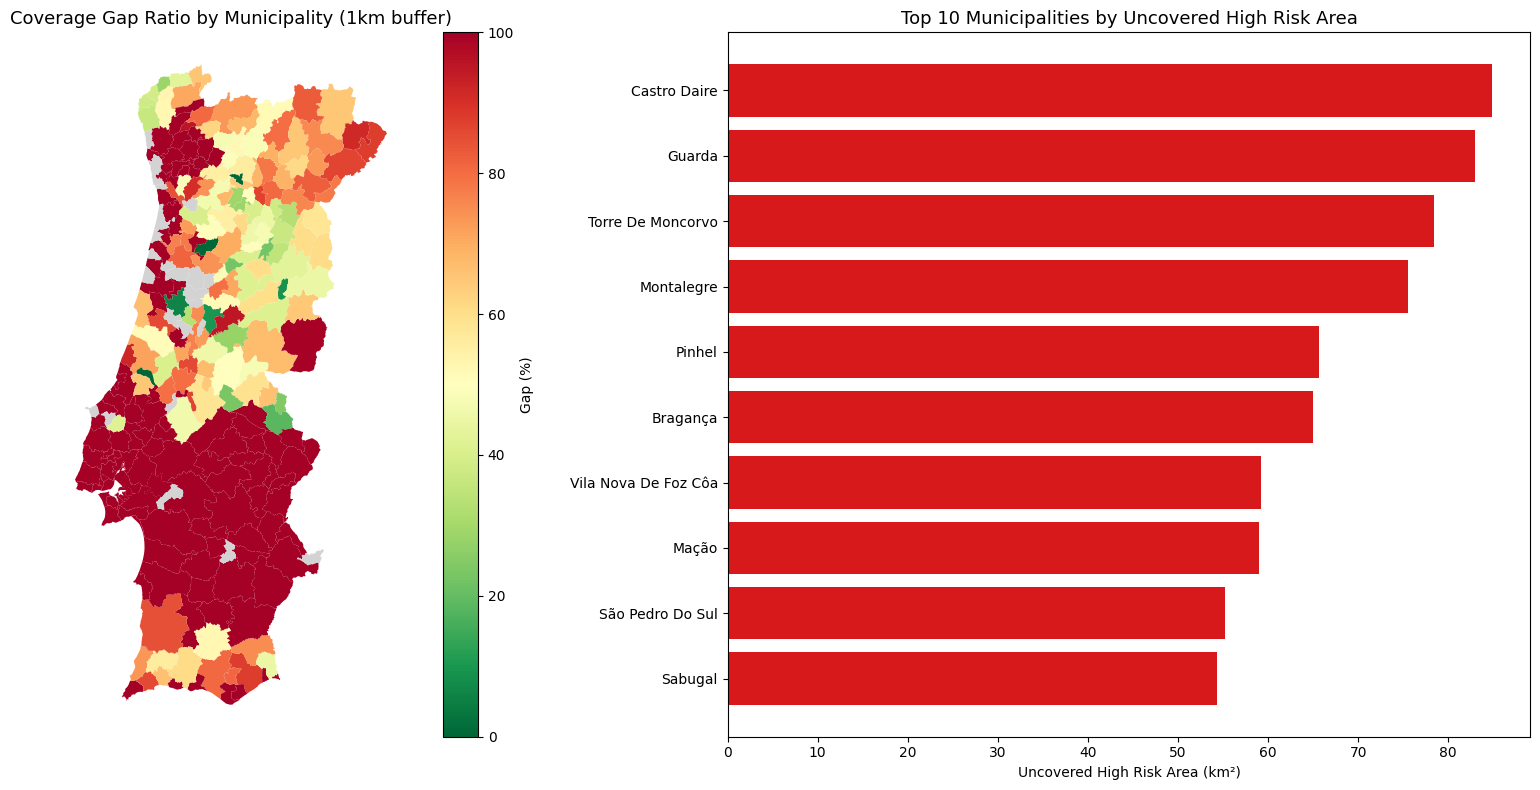

In [30]:
# Join stats back to municipality geodataframe
municipal_geo = municipalities.merge(municipal_df, left_on="NAME", right_on="Municipality", how="left")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Map of gap ratio
municipal_geo.plot(ax=axes[0], column="Gap (%)", cmap="RdYlGn_r",
                   legend=True, missing_kwds={"color": "lightgrey"},
                   legend_kwds={"label": "Gap (%)"})
axes[0].set_title("Coverage Gap Ratio by Municipality (1km buffer)", fontsize=13)
axes[0].set_axis_off()

# Top 10 bar chart by uncovered area
top10 = municipal_significant.head(10)
axes[1].barh(top10["Municipality"], top10["Uncovered (km²)"], color="#d7191c")
axes[1].set_title("Top 10 Municipalities by Uncovered High Risk Area", fontsize=13)
axes[1].set_xlabel("Uncovered High Risk Area (km²)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/municipal_coverage_gaps.png", dpi=150)
plt.show()

### 4.7 Load Social Vulnerability Data
We load the INE 2023 Municipal Purchasing Power Study (Estudo sobre o 
Poder de Compra Concelhio), which provides the per capita income index 
(IpC) for each municipality relative to the national average (base = 100). 
Municipalities below 100 have below-average purchasing power and are 
considered more economically vulnerable. Municipality names are normalised 
through accent removal and lowercasing to allow consistent matching between 
the INE dataset and the municipality shapefile, yielding 278 matched 
municipalities.

In [31]:
vuln_df = pd.read_csv("../data/raw/social_vulnerability/QD5.csv", 
                       encoding="latin1", sep=";", skiprows=3, header=None)
vuln_df.columns = ["Municipality", "IpC", "PPC", "FDR"]

# Convert to float
vuln_df["IpC"] = pd.to_numeric(vuln_df["IpC"].str.replace(",", "."), errors="coerce")
vuln_df["PPC"] = pd.to_numeric(vuln_df["PPC"].str.replace(",", "."), errors="coerce")
vuln_df["FDR"] = pd.to_numeric(vuln_df["FDR"].str.replace(",", "."), errors="coerce")

# Drop NaN rows
vuln_df = vuln_df.dropna(subset=["PPC"])
vuln_df["Municipality"] = vuln_df["Municipality"].str.strip()

# Keep only actual municipalities by matching with shapefile names
muni_names = municipalities["NAME"].str.strip().tolist()
vuln_muni = vuln_df[vuln_df["Municipality"].isin(muni_names)].copy()

print(f"Matched municipalities: {len(vuln_muni)} out of {len(muni_names)}")
print(vuln_muni.head(10))

Matched municipalities: 193 out of 281
   Municipality     IpC    PPC    FDR
5       Caminha   82.12  0.127  0.944
6       Melgaço   64.90  0.046  0.927
7        Monção   75.84  0.129  0.501
11      Valença   84.67  0.113  0.556
15       Amares   75.17  0.138 -0.040
16     Barcelos   82.15  0.903 -0.474
17        Braga  105.49  1.999 -0.525
18    Esposende   88.00  0.307  0.076
20   Vila Verde   75.64  0.342 -0.138
23         Fafe   76.90  0.351 -0.189


In [32]:
matched_names = vuln_muni["Municipality"].tolist()
unmatched = [name for name in muni_names if name not in matched_names]
print(f"Unmatched municipalities ({len(unmatched)}):")
for name in sorted(unmatched)[:20]:
    print(f"  '{name}'")

Unmatched municipalities (87):
  'Agueda'
  'Aguiar Da Beira'
  'Albergaria-A-Velha'
  'Alcacér Do Sal'
  'Alfândega Da Fé'
  'Alter Do Chão'
  'Arcos De Valdevez'
  'Arruda Dos Vinhos'
  'Cabeceiras De Basto'
  'Caldas Da Rainha'
  'Carrazeda De Ansiães'
  'Carregal Do Sal'
  'Castanheira De Pêra'
  'Castelo De Paiva'
  'Castelo De Vide'
  'Celorico Da Beira'
  'Celorico De Basto'
  'Condeixa-A-Nova'
  'Ferreira Do Alentejo'
  'Ferreira Do Zêzere'


In [33]:
# Normalise names for matching
import unicodedata

def normalise_name(name):
    """Lowercase and remove accents for fuzzy matching."""
    name = name.strip().lower()
    name = unicodedata.normalize("NFKD", name)
    name = "".join(c for c in name if not unicodedata.combining(c))
    return name

# Create normalised versions
vuln_df["name_norm"] = vuln_df["Municipality"].apply(normalise_name)
muni_norm = {normalise_name(n): n for n in muni_names}

# Match
vuln_df["matched_name"] = vuln_df["name_norm"].map(muni_norm)
vuln_muni = vuln_df.dropna(subset=["matched_name", "PPC"]).copy()

print(f"Matched municipalities: {len(vuln_muni)} out of {len(muni_names)}")
print(vuln_muni.head(5))

Matched municipalities: 278 out of 281
        Municipality    IpC    PPC    FDR          name_norm  \
4  Arcos de Valdevez  72.53  0.142  0.386  arcos de valdevez   
5            Caminha  82.12  0.127  0.944            caminha   
6            Melgaço  64.90  0.046  0.927            melgaco   
7             Monção  75.84  0.129  0.501             moncao   
8   Paredes de Coura  69.78  0.057 -0.141   paredes de coura   

        matched_name  
4  Arcos De Valdevez  
5            Caminha  
6            Melgaço  
7             Monção  
8   Paredes De Coura  


### 4.8 Create Social Vulnerability Score
We use the per capita income index (IpC) as our vulnerability indicator. 
The index is inverted and normalised to a 0-1 scale so that higher values 
represent greater vulnerability, a score of 1 means the most economically 
vulnerable municipality and 0 the least. The vulnerability scores are then 
joined to the municipality geodataframe using the matched municipality names 
as the common key.

In [34]:
# Use IpC — invert so higher score = more vulnerable
vuln_muni = vuln_muni.copy()
vuln_muni["vulnerability"] = 1 - (
    (vuln_muni["IpC"] - vuln_muni["IpC"].min()) /
    (vuln_muni["IpC"].max() - vuln_muni["IpC"].min())
)

# Join to municipality geodataframe using matched_name
vuln_geo = municipalities.merge(
    vuln_muni[["matched_name", "IpC", "PPC", "vulnerability"]],
    left_on="NAME", right_on="matched_name", how="left"
)

print(f"Municipalities with vulnerability score: {vuln_geo['vulnerability'].notna().sum()}")
print(vuln_geo[["NAME", "IpC", "vulnerability"]].sort_values("vulnerability", ascending=False).head(10))

Municipalities with vulnerability score: 281


                         NAME    IpC  vulnerability
187                   Tabuaço  63.53       1.000000
274                 Penamacor  63.77       0.997963
117                   Vimioso  63.80       0.997708
118                   Vinhais  64.26       0.993804
264                     Baião  64.54       0.991428
266               Sernancelhe  64.72       0.989900
107                   Melgaço  64.90       0.988372
81                   Valpaços  64.93       0.988117
189  Santa Marta De Penaguião  65.00       0.987523
72          Celorico De Basto  65.08       0.986844


### 4.9 Visualise Social Vulnerability
We map the vulnerability score per municipality across mainland Portugal. 
Darker colours indicate higher vulnerability, meaning lower per capita 
income relative to the national average. The map reveals a clear geographic 
pattern, with the highest vulnerability concentrated in the interior 
northern and central municipalities.

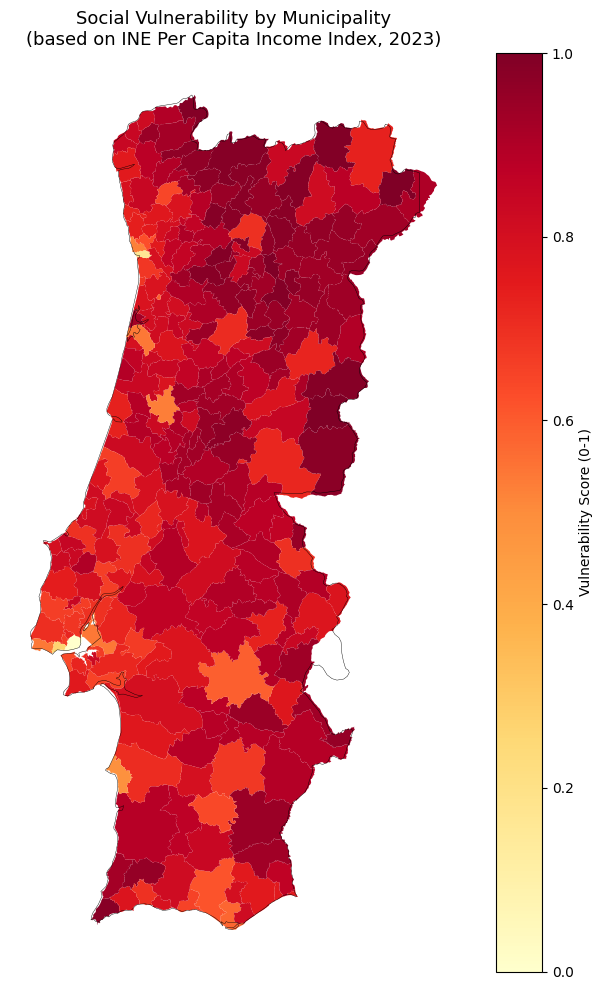

In [35]:
fig, ax = plt.subplots(figsize=(8, 10))
vuln_geo.plot(ax=ax, column="vulnerability", cmap="YlOrRd",
              legend=True, missing_kwds={"color": "lightgrey"},
              legend_kwds={"label": "Vulnerability Score (0-1)"})
portugal_mainland.plot(ax=ax, color="none", edgecolor="black", linewidth=0.3)
ax.set_title("Social Vulnerability by Municipality\n(based on INE Per Capita Income Index, 2023)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/vulnerability_map.png", dpi=150)
plt.show()

## 5. Inequality Analysis
### 5.1 Combine Coverage Gaps and Vulnerability
We join the municipal coverage gap statistics with the vulnerability scores 
to test whether municipalities with higher social vulnerability also face 
greater gaps in wildfire prevention coverage. Municipalities with no high 
risk area are excluded from this analysis since a coverage gap cannot be 
calculated without any high risk territory to measure it against.

In [36]:
# Join municipal stats with vulnerability
analysis_df = municipal_geo.merge(
    vuln_geo[["NAME", "IpC", "vulnerability"]],
    on="NAME", how="left"
)

# Drop municipalities with no high risk area
analysis_df = analysis_df[analysis_df["High Risk Area (km²)"] > 0].copy()

print(f"Municipalities with high risk area: {len(analysis_df)}")
print(analysis_df[["NAME", "High Risk Area (km²)", "Gap (%)", "vulnerability"]].head(10))

Municipalities with high risk area: 272
            NAME  High Risk Area (km²)  Gap (%)  vulnerability
0        Setúbal                  0.44    100.0       0.650569
1  Vila Do Bispo                  2.50    100.0       0.980479
2       Sesimbra                  3.88    100.0       0.759803
3          Moura                  1.38    100.0       0.888304
4         Tavira                  9.50     87.5       0.754371
5          Loulé                  6.81     80.7       0.617128
6         Mourão                  0.75    100.0       0.932100
7          Lagos                  1.75     85.7       0.776269
8          Lagoa                  0.12    100.0       0.788236
9           Faro                  0.81    100.0       0.577661


### 5.2 Scatter Plot — Vulnerability vs Coverage Gap
We plot the relationship between vulnerability score and coverage gap ratio 
for each municipality to directly answer the core inequality question of 
this study: are prevention coverage gaps disproportionately concentrated 
in the most socially vulnerable municipalities? Each point represents one 
municipality, coloured by the size of its total high risk area. A trend 
line is fitted to show the direction and strength of the relationship, 
with the Pearson correlation coefficient and p-value reported.

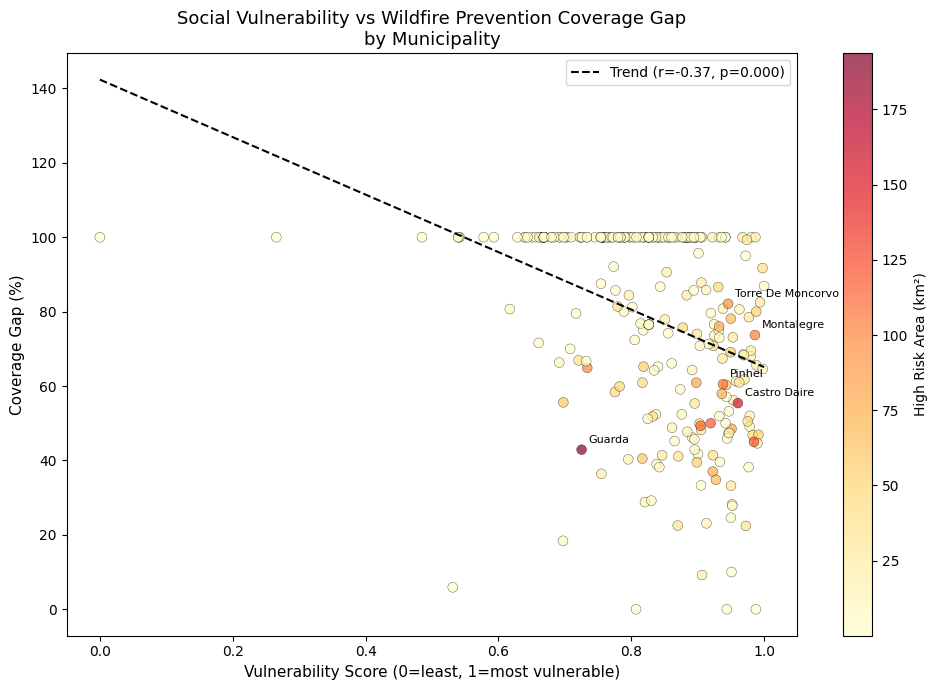


Correlation: r=-0.368, p-value=0.0000


In [37]:
# Scatter plot: Vulnerability Score vs Coverage Gap Ratio
# Coloured by priority level to show the relationship between
# economic vulnerability and relative prevention coverage gaps
# Scatter plot: Vulnerability Score vs Coverage Gap Ratio
# Coloured by priority level to show the relationship between
# economic vulnerability and relative prevention coverage gaps
from scipy import stats

# Drop rows with missing values
scatter_df = analysis_df.dropna(subset=["Gap (%)", "vulnerability"])

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    scatter_df["vulnerability"],
    scatter_df["Gap (%)"],
    c=scatter_df["High Risk Area (km²)"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.3,
    s=50
)

# Trend line
slope, intercept, r, p, se = stats.linregress(
    scatter_df["vulnerability"], scatter_df["Gap (%)"]
)
x_line = np.linspace(scatter_df["vulnerability"].min(), scatter_df["vulnerability"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="black", linewidth=1.5, linestyle="--", label=f"Trend (r={r:.2f}, p={p:.3f})")

# Label top 5 most critical municipalities
top5 = scatter_df.nlargest(5, "Uncovered (km²)")
for _, row in top5.iterrows():
    ax.annotate(row["NAME"], (row["vulnerability"], row["Gap (%)"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.colorbar(scatter, ax=ax, label="High Risk Area (km²)")
ax.set_xlabel("Vulnerability Score (0=least, 1=most vulnerable)", fontsize=11)
ax.set_ylabel("Coverage Gap (%)", fontsize=11)
ax.set_title("Social Vulnerability vs Wildfire Prevention Coverage Gap\nby Municipality", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/scatter_vulnerability_gap.png", dpi=150)
plt.show()

print(f"\nCorrelation: r={r:.3f}, p-value={p:.4f}")

### 5.3 Scatter Plot — Vulnerability vs Absolute Uncovered Area
We complement the previous scatter plot by examining the relationship 
between vulnerability score and the absolute area of unprotected high 
risk territory in km² per municipality. While the previous plot shows 
the relative gap ratio, this plot reveals the absolute scale of the 
problem. A positive trend indicates that more economically vulnerable 
municipalities tend to have larger absolute unprotected high risk areas, 
even if their relative gap ratio is not the highest.

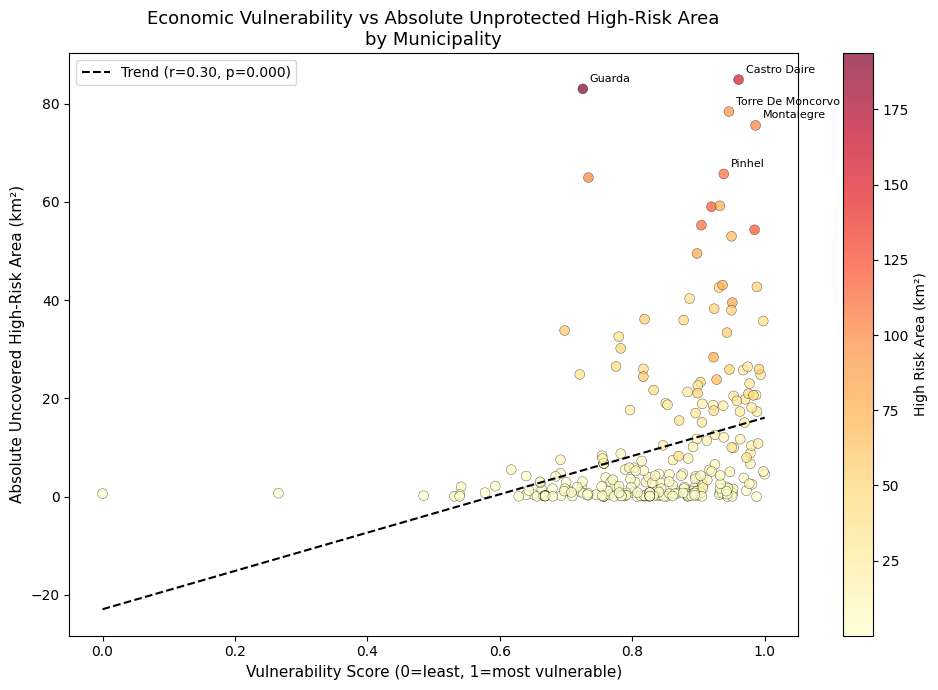


Correlation: r=0.304, p-value=0.0000


In [38]:
# Scatter plot: Vulnerability Score vs Absolute Uncovered Area
# Coloured by total high-risk area size

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    scatter_df["vulnerability"],
    scatter_df["Uncovered (km²)"],
    c=scatter_df["High Risk Area (km²)"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.3,
    s=50
)

# Trend line
slope, intercept, r, p, se = stats.linregress(
    scatter_df["vulnerability"], scatter_df["Uncovered (km²)"]
)
x_line = np.linspace(scatter_df["vulnerability"].min(),
                     scatter_df["vulnerability"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="black",
        linewidth=1.5, linestyle="--",
        label=f"Trend (r={r:.2f}, p={p:.3f})")

# Annotate top 5 by uncovered area
top5 = scatter_df.nlargest(5, "Uncovered (km²)")
for _, row in top5.iterrows():
    ax.annotate(row["NAME"],
                (row["vulnerability"], row["Uncovered (km²)"]),
                fontsize=8, xytext=(5, 5),
                textcoords="offset points")

plt.colorbar(scatter, ax=ax, label="High Risk Area (km²)")
ax.set_xlabel("Vulnerability Score (0=least, 1=most vulnerable)", fontsize=11)
ax.set_ylabel("Absolute Uncovered High-Risk Area (km²)", fontsize=11)
ax.set_title("Economic Vulnerability vs Absolute Unprotected High-Risk Area\nby Municipality",
             fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/scatter_vulnerability_absolute.png", dpi=150)
plt.show()

print(f"\nCorrelation: r={r:.3f}, p-value={p:.4f}")

### 5.4 Priority Classification
We classify each municipality into one of five priority levels for policy 
intervention by combining their gap ratio, vulnerability score and total 
high risk area. The median gap ratio and median vulnerability score are 
used as thresholds to assign each municipality to a priority level. 
Municipalities above both medians and with a high risk area of at least 
10km² are classified as Very High priority, representing the most urgent 
cases for targeted prevention investment.

In [39]:
# Define priority based on gap and vulnerability thresholds
# Using median as threshold for each dimension
gap_threshold = scatter_df["Gap (%)"].median()
vuln_threshold = scatter_df["vulnerability"].median()

print(f"Gap threshold (median): {gap_threshold:.1f}%")
print(f"Vulnerability threshold (median): {vuln_threshold:.3f}")

def assign_priority(row):
    high_gap = row["Gap (%)"] >= gap_threshold
    high_vuln = row["vulnerability"] >= vuln_threshold
    high_risk = row["High Risk Area (km²)"] >= 10
    
    if high_gap and high_vuln and high_risk:
        return "Very High"
    elif high_gap and high_vuln:
        return "High"
    elif high_gap and not high_vuln:
        return "Medium"
    elif not high_gap and high_vuln:
        return "Low-Medium"
    else:
        return "Low"

scatter_df["Priority"] = scatter_df.apply(assign_priority, axis=1)

print("\nPriority distribution:")
print(scatter_df["Priority"].value_counts())

Gap threshold (median): 86.8%
Vulnerability threshold (median): 0.851

Priority distribution:
Priority
Medium        92
Low-Medium    92
Low           44
High          35
Very High      9
Name: count, dtype: int64


### 5.5 Priority Map
We map the priority classification across mainland Portugal and show the 
top priority municipalities by absolute uncovered high risk area in a bar 
chart. The map identifies where targeted policy intervention is most 
urgently needed, combining coverage gaps, vulnerability and the scale of 
unprotected high risk territory into a single actionable classification.

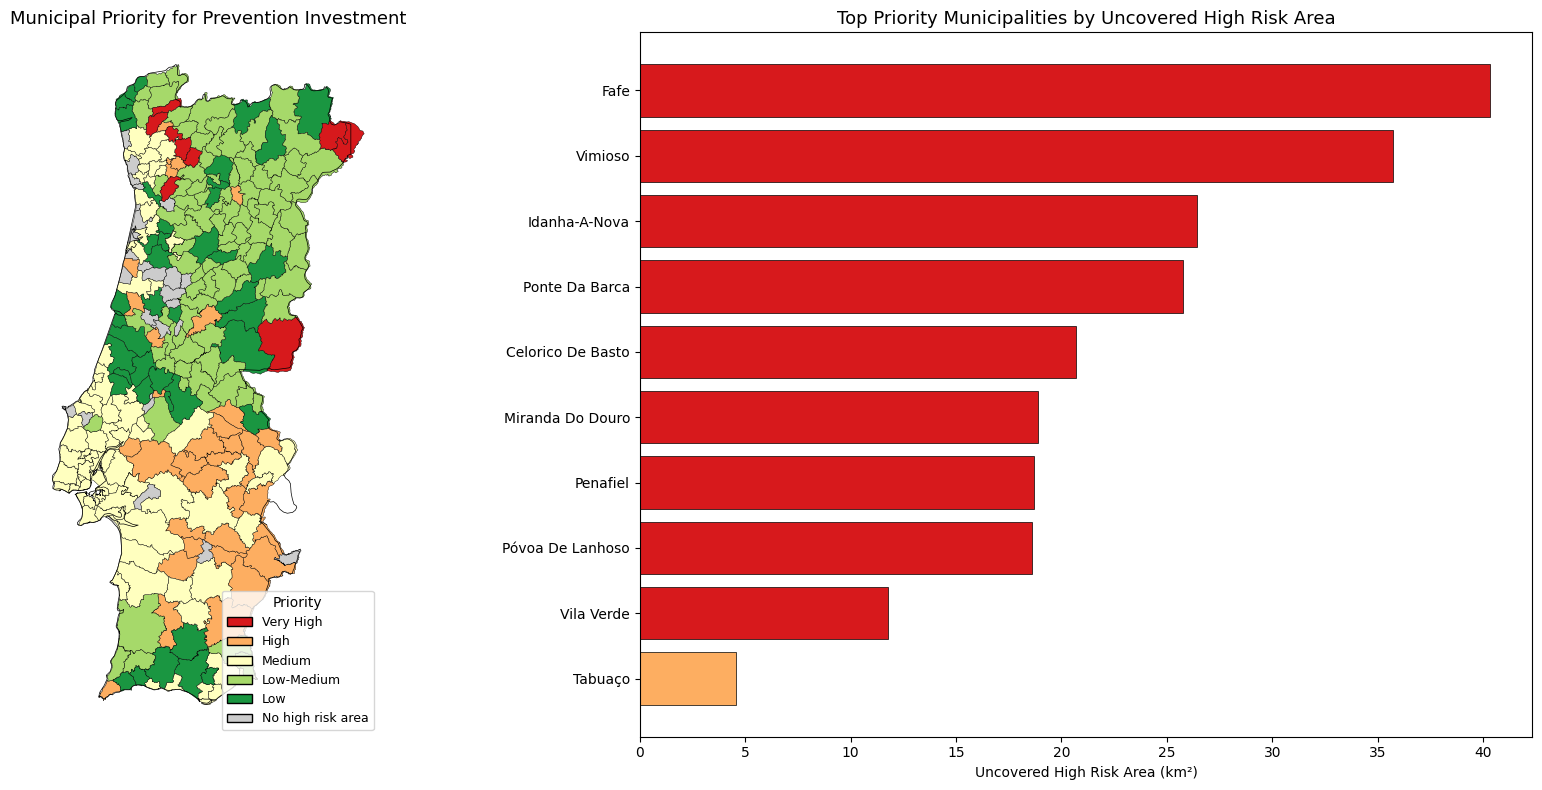

In [40]:
# Join priority back to geodataframe
priority_geo = municipalities.merge(
    scatter_df[["NAME", "Priority", "Gap (%)", "vulnerability", "High Risk Area (km²)"]],
    on="NAME", how="left"
)

# Define colour mapping
priority_colors = {
    "Very High": "#d7191c",
    "High": "#fdae61",
    "Medium": "#ffffbf",
    "Low-Medium": "#a6d96a",
    "Low": "#1a9641"
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Priority map
priority_geo["color"] = priority_geo["Priority"].map(priority_colors).fillna("#cccccc")
priority_geo.plot(ax=axes[0], color=priority_geo["color"], edgecolor="black", linewidth=0.3)
portugal_mainland.plot(ax=axes[0], color="none", edgecolor="black", linewidth=0.5)

legend_elements = [Patch(facecolor=c, edgecolor="black", label=p) 
                   for p, c in priority_colors.items()]
legend_elements.append(Patch(facecolor="#cccccc", edgecolor="black", label="No high risk area"))
axes[0].legend(handles=legend_elements, loc="lower right", 
               fontsize=9, title="Priority", bbox_to_anchor=(1.0, 0.0))
axes[0].set_title("Municipal Priority for Prevention Investment", fontsize=13)
axes[0].set_axis_off()

# Top priority bar chart
top_priority = scatter_df[scatter_df["Priority"].isin(["Very High", "High"])]\
    .sort_values("Uncovered (km²)", ascending=False).head(10)

colors_bar = [priority_colors[p] for p in top_priority["Priority"]]
axes[1].barh(top_priority["NAME"], top_priority["Uncovered (km²)"],
             color=colors_bar, edgecolor="black", linewidth=0.5)
axes[1].set_title("Top Priority Municipalities by Uncovered High Risk Area", fontsize=13)
axes[1].set_xlabel("Uncovered High Risk Area (km²)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/priority_map.png", dpi=150)
plt.show()

In [41]:
print(scatter_df[scatter_df["Priority"].isin(["High", "Very High"])][["NAME", "Priority", "Gap (%)", "vulnerability", "High Risk Area (km²)"]].sort_values("Priority").to_string(index=False))

                  NAME  Priority  Gap (%)  vulnerability  High Risk Area (km²)
         Vila Do Bispo      High    100.0       0.980479                  2.50
                 Borba      High    100.0       0.883297                  0.56
                  Avis      High    100.0       0.897131                  0.25
             Arraiolos      High    100.0       0.878204                  1.62
                  Mora      High    100.0       0.856052                  0.62
               Redondo      High    100.0       0.892718                  0.75
                 Crato      High    100.0       0.897301                  1.12
         Alter Do Chão      High    100.0       0.882533                  0.38
                Sousel      High    100.0       0.906383                  2.25
             Fronteira      High    100.0       0.881175                  0.62
               Coruche      High    100.0       0.864369                  0.62
Vila Nova Da Barquinha      High    100.0       0.88

### 5.6 Correlation Heatmap
We compute a correlation matrix between the key municipal indicators: 
high risk area, coverage ratio, gap ratio and vulnerability score. 
This gives an overview of how these dimensions relate to each other 
and confirms whether the patterns identified in the scatter plots 
hold across the full set of indicators.

In [42]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

0

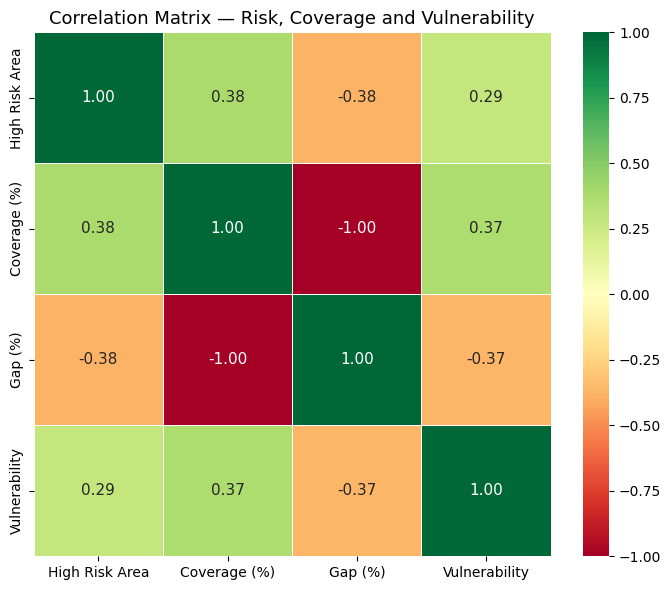

In [43]:
import seaborn as sns

corr_df = scatter_df[["High Risk Area (km²)", "Coverage (%)", "Gap (%)", "vulnerability"]].copy()
corr_df.columns = ["High Risk Area", "Coverage (%)", "Gap (%)", "Vulnerability"]

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={"size": 11})
ax.set_title("Correlation Matrix — Risk, Coverage and Vulnerability", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150)
plt.show()

### Interpretation of Correlation Heatmap
The correlation matrix confirms and extends the findings from the scatter plot:

- **Coverage (%) and Gap (%) show a perfect inverse correlation (-1.00)** — 
  this is expected since they are mathematical complements of each other.

- **High Risk Area and Coverage (%) show a moderate positive correlation (0.38)** — 
  municipalities with larger high risk areas tend to have better coverage. 
  This supports the idea that the fuel network was placed where fire risk is 
  highest, rather than randomly or based on other criteria.

- **Vulnerability and Coverage (%) show a moderate positive correlation (0.37)** — 
  more vulnerable municipalities tend to have slightly better coverage, 
  consistent with the scatter plot finding that the network broadly follows 
  risk patterns in the interior where vulnerability is also highest.

- **Vulnerability and Gap (%) show a moderate negative correlation (-0.37)** — 
  confirming that more vulnerable municipalities do not systematically face 
  larger gaps in relative terms.

Overall, the heatmap suggests that the primary fuel management network is 
broadly aligned with both fire risk and territorial vulnerability. However, 
as shown in the priority analysis, several highly vulnerable municipalities 
still have large absolute areas of uncovered high risk land, pointing to 
the need for targeted expansion of prevention infrastructure in these territories.